In [19]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from pathlib import Path

print(Path.cwd())

d:\TalnetGuard_Ai\notebooks


In [22]:
from pathlib import Path

print(list(Path("../backend/models").glob("*")))

[WindowsPath('../backend/models/attrition_pipeline.pkl'), WindowsPath('../backend/models/shap_explainer.pkl'), WindowsPath('../backend/models/threshold.pkl')]


In [23]:
import joblib
import shap

pipeline = joblib.load("../backend/models/attrition_pipeline.pkl")

print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [24]:
print(pipeline.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


In [25]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]

print(type(preprocessor))
print(type(model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [26]:
import shap
explainer = shap.TreeExplainer(model)

print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [28]:
model = pipeline.named_steps["classifier"]

In [29]:
explainer = shap.TreeExplainer(model)

In [31]:
from pathlib import Path

print(list(Path("../backend/models").glob("*")))

[WindowsPath('../backend/models/attrition_pipeline.pkl'), WindowsPath('../backend/models/shap_explainer.pkl'), WindowsPath('../backend/models/threshold.pkl')]


In [32]:
pipeline = joblib.load("../backend/models/shap_explainer.pkl")

In [33]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [34]:
X_test_transformed = preprocessor.transform(X_test)

In [35]:
feature_names = preprocessor.get_feature_names_out()

In [36]:
shap_values = explainer.shap_values(X_test_transformed)

In [37]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [38]:
print(shap_values.shape)

print(X_test_transformed.shape)

print(len(feature_names))

(294, 51, 2)
(294, 51)
51


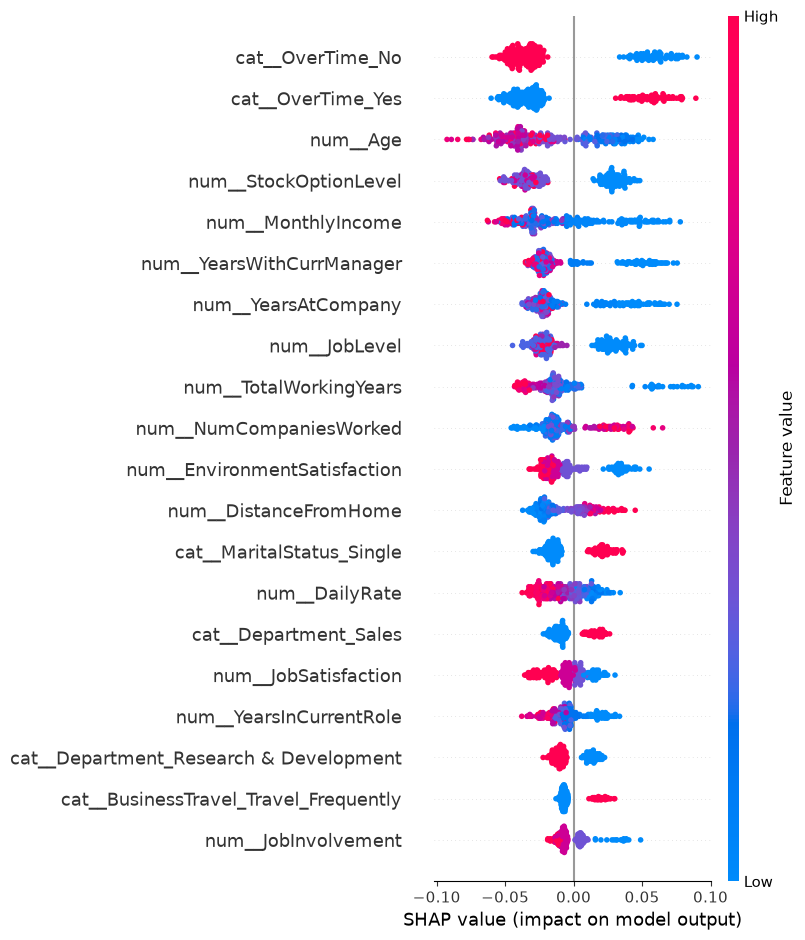

In [39]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)

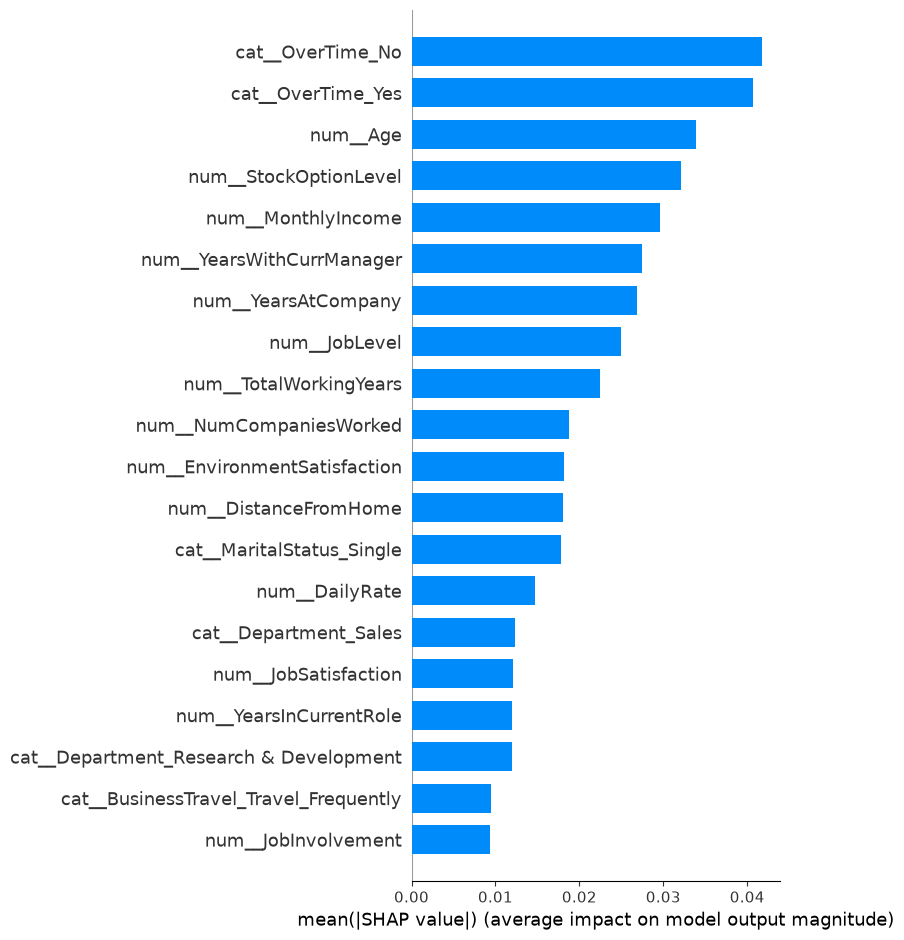

In [40]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [41]:
employee_index = 0

employee_shap = pd.DataFrame({

    "Feature": feature_names,

    "SHAP Value": shap_values[employee_index, :, 1]

})

employee_shap["Absolute"] = employee_shap["SHAP Value"].abs()

employee_shap = employee_shap.sort_values(
    "Absolute",
    ascending=False
)

employee_shap.head(10)

,Feature,SHAP Value,Absolute
44,num__TotalWorkingYears,0.083586,0.083586
50,num__YearsWithCurrManager,0.072852,0.072852
47,num__YearsAtCompany,0.066571,0.066571
37,num__MonthlyIncome,0.062388,0.062388
28,num__Age,0.044047,0.044047
26,cat__OverTime_No,-0.031357,0.031357
27,cat__OverTime_Yes,-0.029853,0.029853
35,num__JobLevel,0.029109,0.029109
0,cat__BusinessTravel_Non-Travel,-0.028414,0.028414
48,num__YearsInCurrentRole,0.027927,0.027927


In [42]:
employee_shap["Impact"] = employee_shap["SHAP Value"].apply(
    lambda x: "Increases Attrition Risk" if x > 0 else "Decreases Attrition Risk"
)

employee_shap["SHAP Value"] = employee_shap["SHAP Value"].round(4)

employee_shap = employee_shap[
    ["Feature", "SHAP Value", "Impact"]
]

employee_shap.head(10)

,Feature,SHAP Value,Impact
44,num__TotalWorkingYears,0.0836,Increases Attrition Risk
50,num__YearsWithCurrManager,0.0729,Increases Attrition Risk
47,num__YearsAtCompany,0.0666,Increases Attrition Risk
37,num__MonthlyIncome,0.0624,Increases Attrition Risk
28,num__Age,0.0440,Increases Attrition Risk
26,cat__OverTime_No,-0.0314,Decreases Attrition Risk
27,cat__OverTime_Yes,-0.0299,Decreases Attrition Risk
35,num__JobLevel,0.0291,Increases Attrition Risk
0,cat__BusinessTravel_Non-Travel,-0.0284,Decreases Attrition Risk
48,num__YearsInCurrentRole,0.0279,Increases Attrition Risk


In [43]:
top_positive = employee_shap[
    employee_shap["Impact"] == "Increases Attrition Risk"
].head(5)

print("Top reasons why the employee is at risk:\n")

for _, row in top_positive.iterrows():
    print(f"• {row['Feature']} (SHAP = {row['SHAP Value']})")

Top reasons why the employee is at risk:

• num__TotalWorkingYears (SHAP = 0.0836)
• num__YearsWithCurrManager (SHAP = 0.0729)
• num__YearsAtCompany (SHAP = 0.0666)
• num__MonthlyIncome (SHAP = 0.0624)
• num__Age (SHAP = 0.044)


In [44]:
print(explainer.expected_value)

[0.49927721 0.50072279]


In [45]:
explainer.expected_value[1]

np.float64(0.5007227891156468)

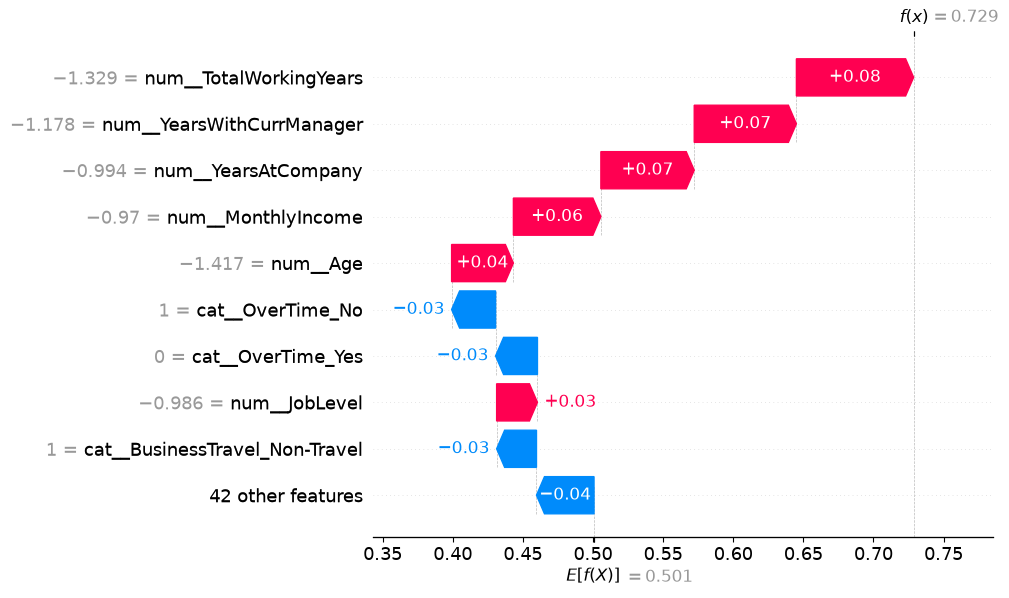

In [46]:
employee_index = 0

explanation = shap.Explanation(
    values=shap_values[employee_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_transformed[employee_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=10)

In [49]:
employee_shap["Feature"] = employee_shap["Feature"].replace(feature_mapping)

In [51]:
employee_shap["SHAP Value"] = employee_shap["SHAP Value"].round(3)

In [53]:
employee_shap["Feature"] = employee_shap["Feature"].apply(clean_feature_name)

In [54]:
employee_shap["Direction"] = employee_shap["SHAP Value"].apply(
    lambda x: "Increase" if x > 0 else "Decrease"
)

In [58]:
print(type(shap_values))
print(type(vals))

print(np.array(vals).shape)

print(len(feature_names))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(51, 2)
51


In [60]:
import pandas as pd
import numpy as np

# ============================================================
# Extract SHAP values for the Attrition = Yes class
# ============================================================

if isinstance(shap_values, list):
    vals = shap_values[1][0]

elif hasattr(shap_values, "values"):

    vals = shap_values.values

    # (1, n_features, 2)
    if vals.ndim == 3:
        vals = vals[0, :, 1]

    # (n_features, 2)
    elif vals.ndim == 2:
        vals = vals[:, 1]

    # (n_features,)
    elif vals.ndim == 1:
        pass

    else:
        raise ValueError(f"Unexpected SHAP shape: {vals.shape}")

else:

    vals = np.asarray(shap_values)

    if vals.ndim == 3:
        vals = vals[0, :, 1]

    elif vals.ndim == 2:
        vals = vals[:, 1]

print("Feature names:", len(feature_names))
print("SHAP values :", len(vals))

# ============================================================
# Build DataFrame
# ============================================================

shap_df = pd.DataFrame({
    "encoded_feature": feature_names,
    "shap_value": vals
})

# ============================================================
# Recover original feature names
# ============================================================

def get_original_feature(name):

    if name.startswith("num__"):
        return name.replace("num__", "")

    if name.startswith("cat__"):

        name = name.replace("cat__", "")

        # OverTime_Yes -> OverTime
        return name.split("_")[0]

    return name

shap_df["feature"] = shap_df["encoded_feature"].apply(get_original_feature)

# ============================================================
# Merge One-Hot Encoded Features
# ============================================================

summary = (
    shap_df
    .groupby("feature", as_index=False)["shap_value"]
    .sum()
)

summary["importance"] = summary["shap_value"].abs()

summary = summary.sort_values(
    "importance",
    ascending=False
)

summary.reset_index(drop=True, inplace=True)

summary.head(20)

Feature names: 51
SHAP values : 51


,feature,shap_value,importance
0,TotalWorkingYears,0.083586,0.083586
1,YearsWithCurrManager,0.072852,0.072852
2,YearsAtCompany,0.066571,0.066571
3,MonthlyIncome,0.062388,0.062388
4,OverTime,-0.061210,0.061210
5,Age,0.044047,0.044047
6,BusinessTravel,-0.035886,0.035886
7,JobLevel,0.029109,0.029109
8,YearsInCurrentRole,0.027927,0.027927
9,StockOptionLevel,-0.026565,0.026565
